# Fouille de processus

## Case study

#### Avec Aaron, Julien, Léo, Valentin et Zakaria

### About the log:

##### Traces analysis

#### Dependencies

In [4]:
import os
import pm4py
import matplotlib.pyplot as plt
import pandas as pd

In [5]:
# Function to load XES files from a directory
def load_xes_files(directory):
    xes_files = [os.path.join(directory, file) for file in os.listdir(directory) if file.endswith('.xes')]
    return xes_files

directory = 'datasets'
xes_files = load_xes_files(directory)
event_logs = [pm4py.read_xes(file) for file in xes_files]

parsing log, completed traces :: 100%|██████████| 10000/10000 [00:09<00:00, 1048.73it/s]


### Sampling the log
**Process discovery ($\alpha$-Algorythm)**

Petri net discovered for file renting_log_high.xes


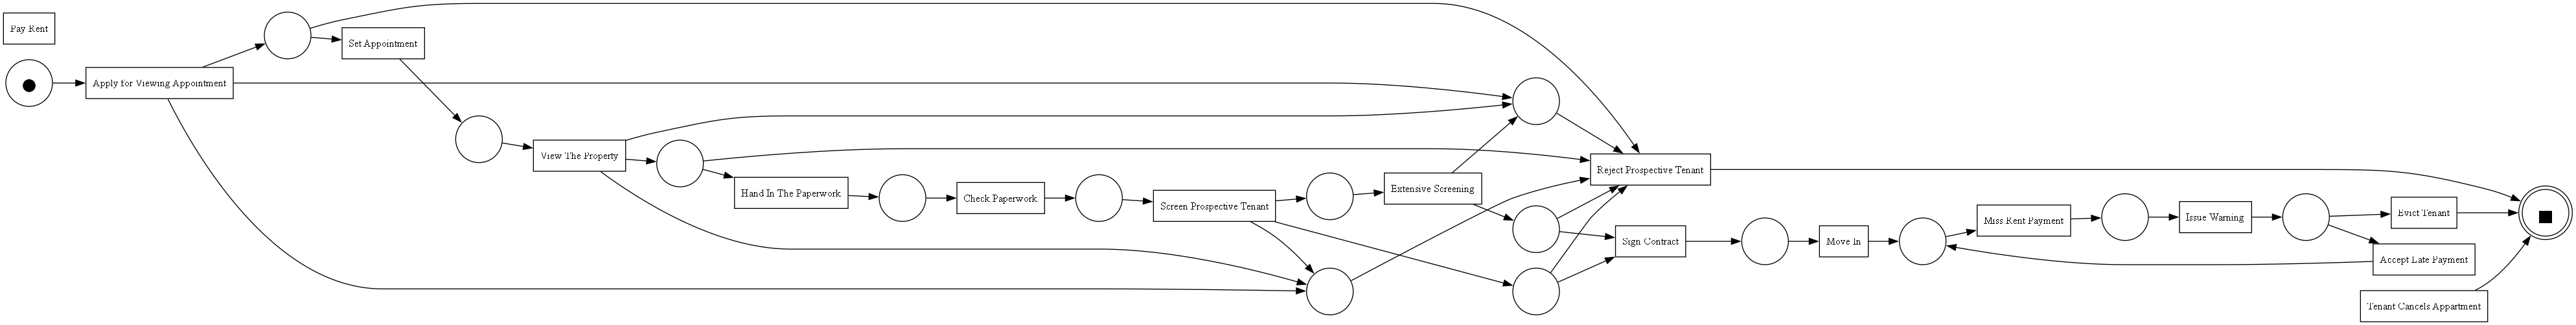

Petri net discovered for file renting_log_low.xes


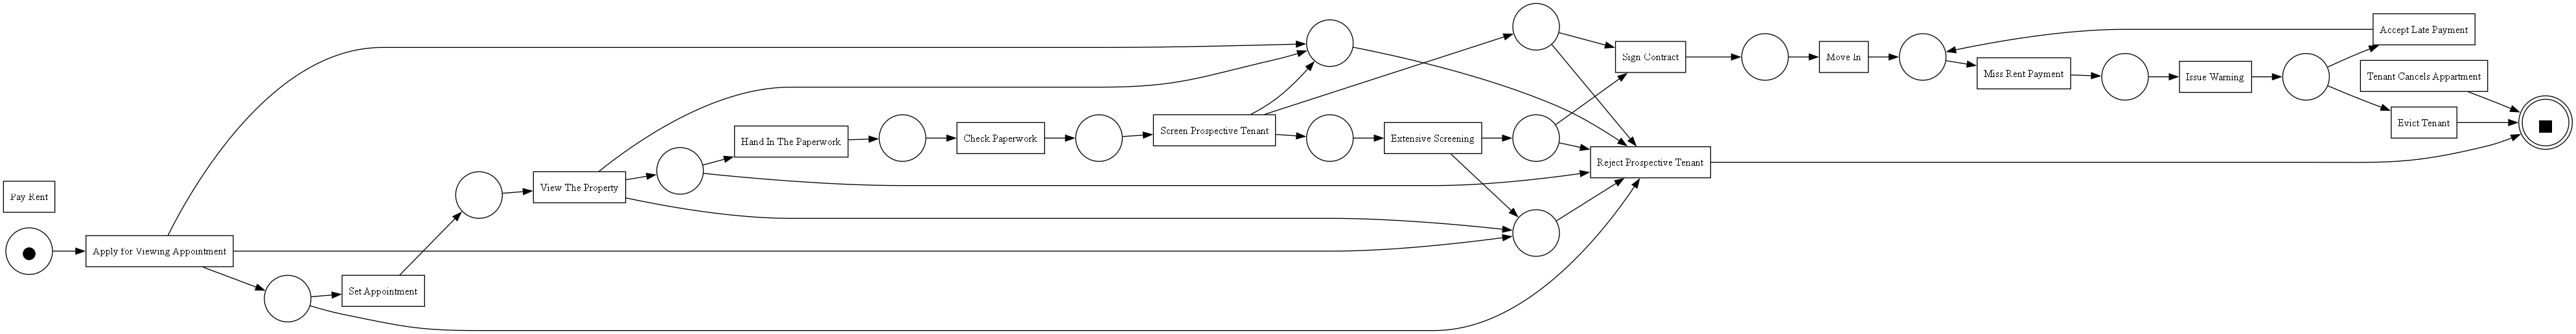

Petri net discovered for file renting_log_medium.xes


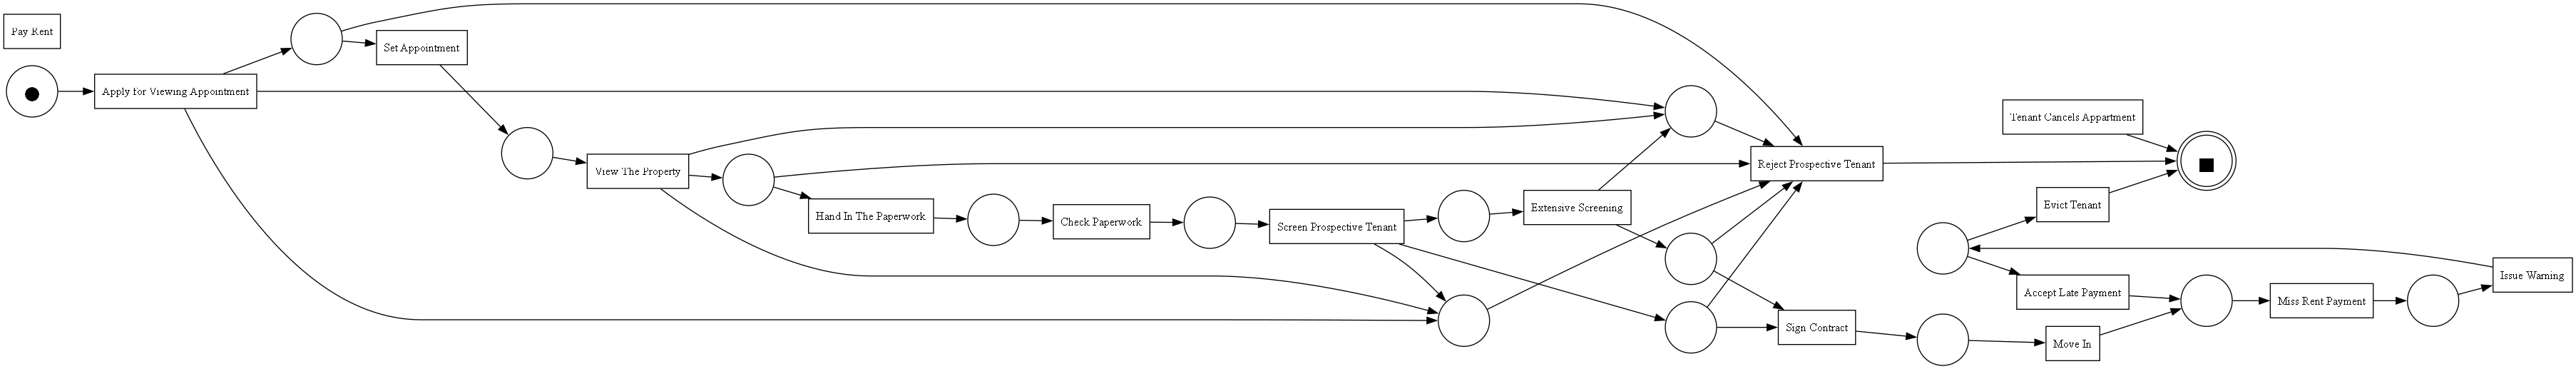

In [6]:
alpha_models = []

#trying the alpha algorithm
for index, event_log in enumerate(event_logs): 
    file_name = xes_files[index].split("\\")[-1]
    net, initial_marking, final_marking = pm4py.discover_petri_net_alpha(event_log)
    alpha_models.append({file_name + " (Petri from alpha miner)" : {"net": net, "initial_marking" : initial_marking, "final_marking" : final_marking}})
    print("Petri net discovered for file", file_name)
    pm4py.view_petri_net(net, initial_marking, final_marking)

### Visualize discriminant metrics
We'll visualize the difference between mutiple variables to see when a trace achieves the event "Sign Contract".

Plot discriminant factors for renting_log_high.xes


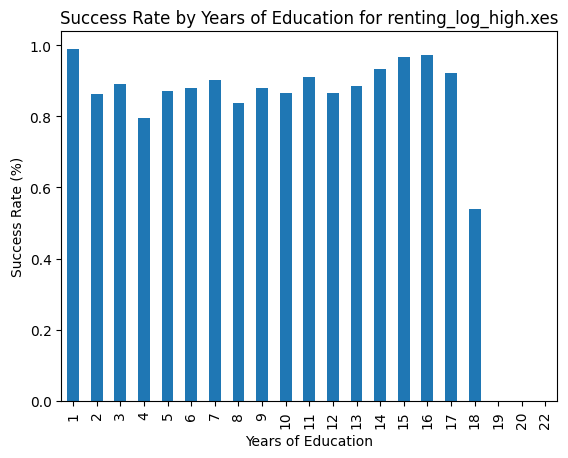

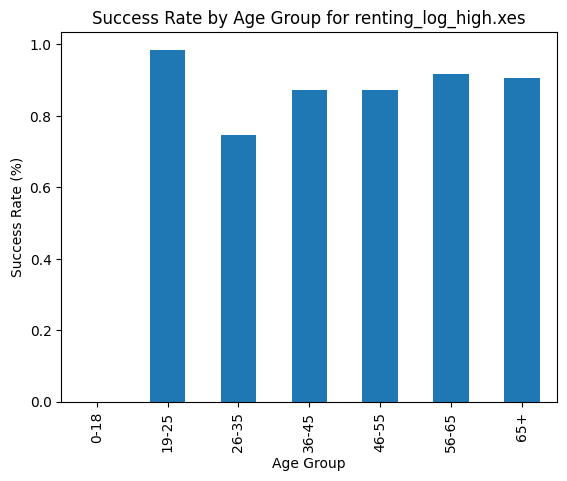

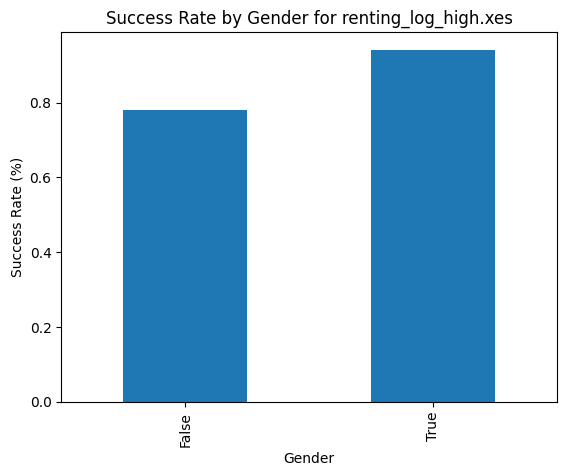

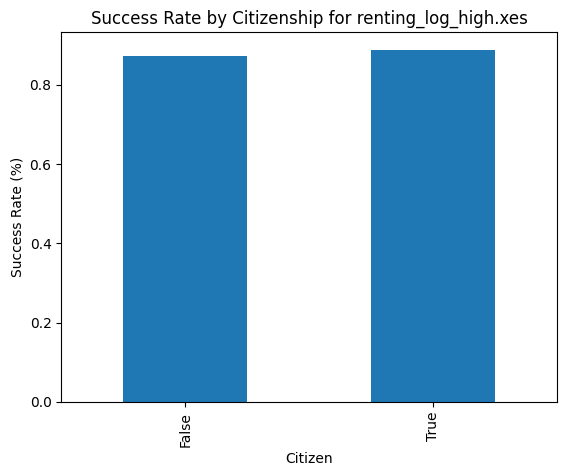

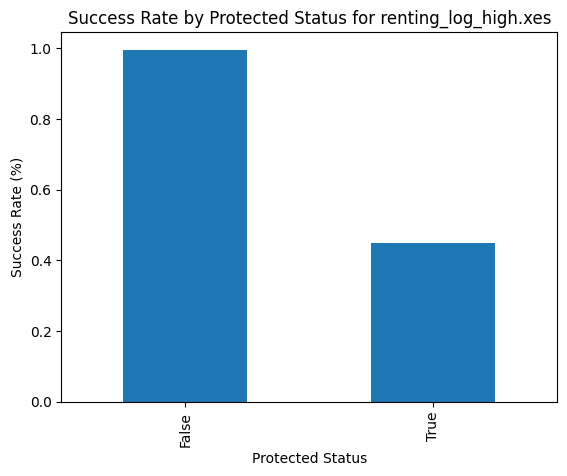

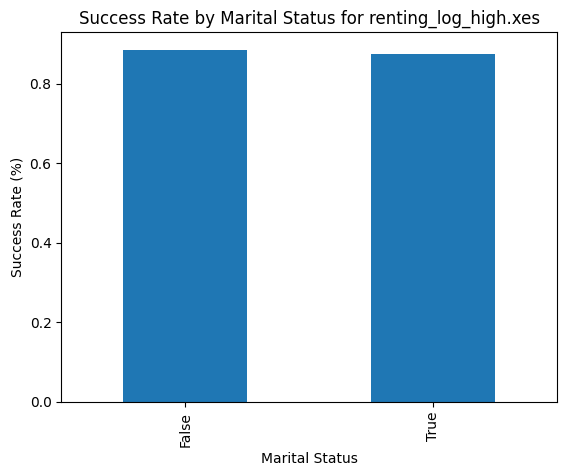

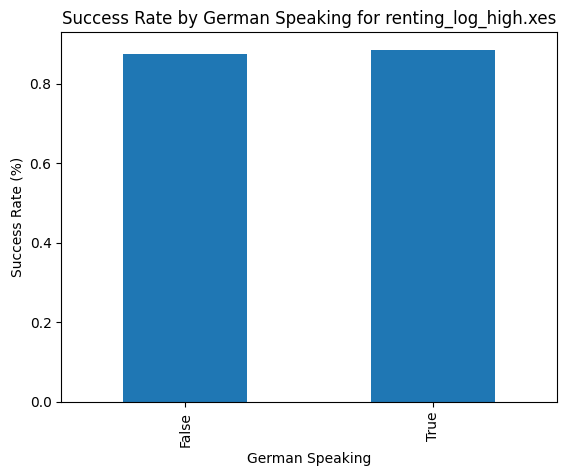

-------------------------
Plot discriminant factors for renting_log_low.xes


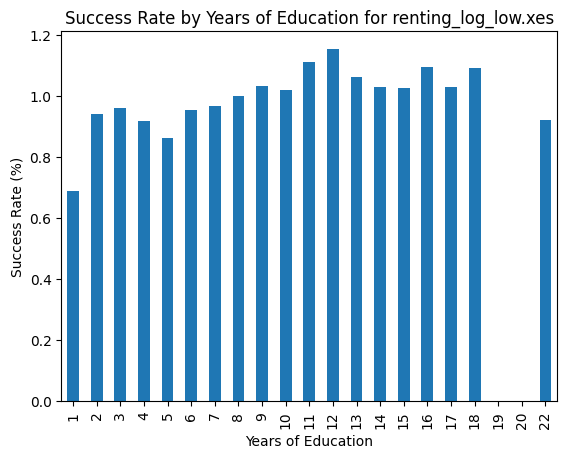

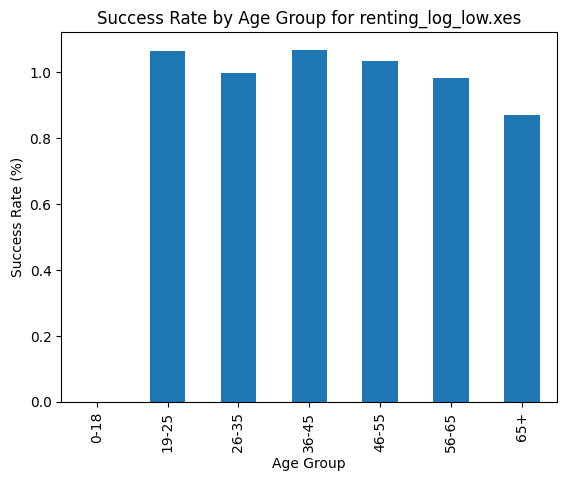

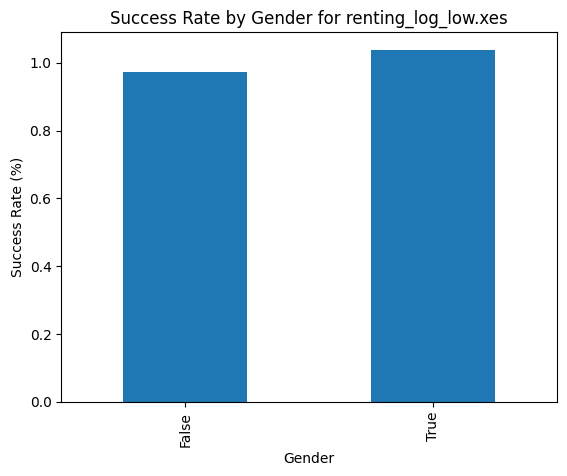

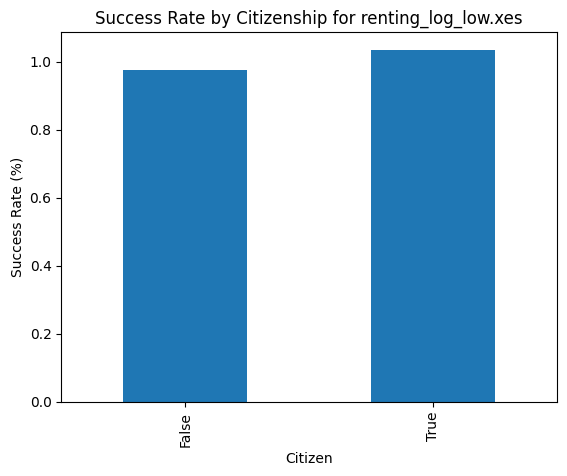

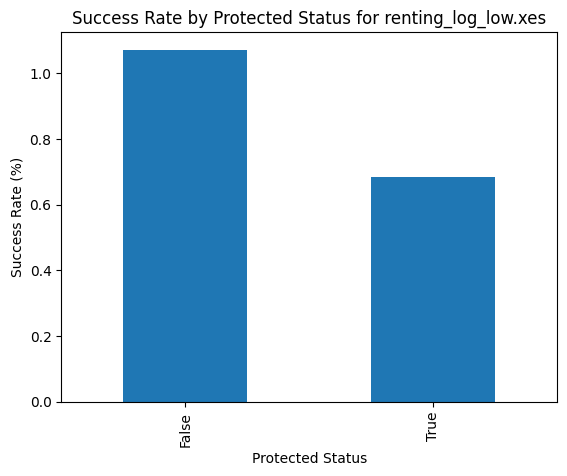

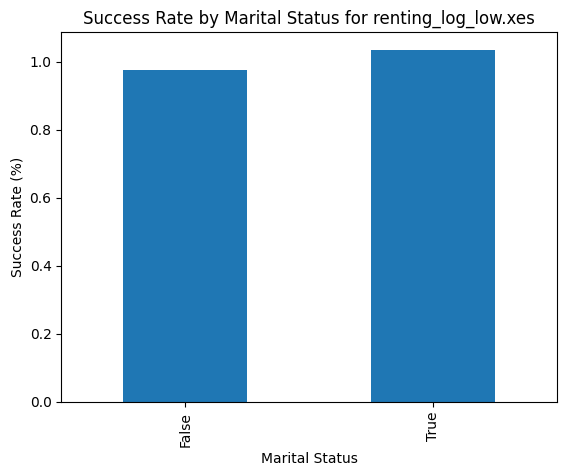

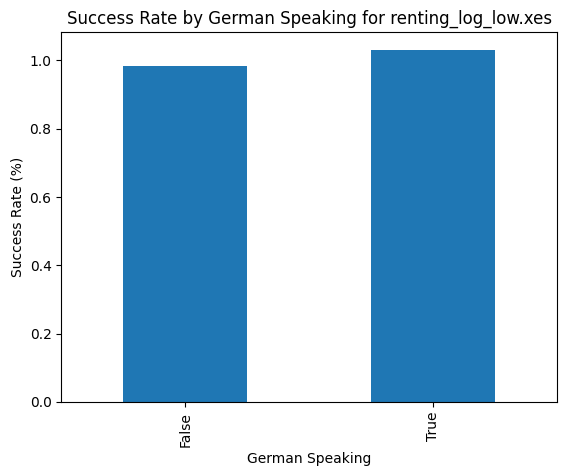

-------------------------
Plot discriminant factors for renting_log_medium.xes


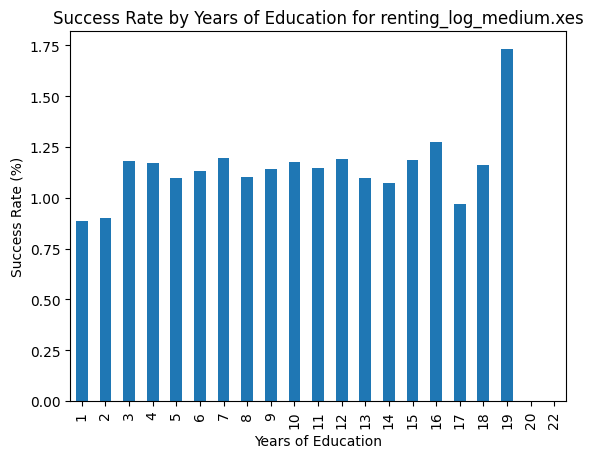

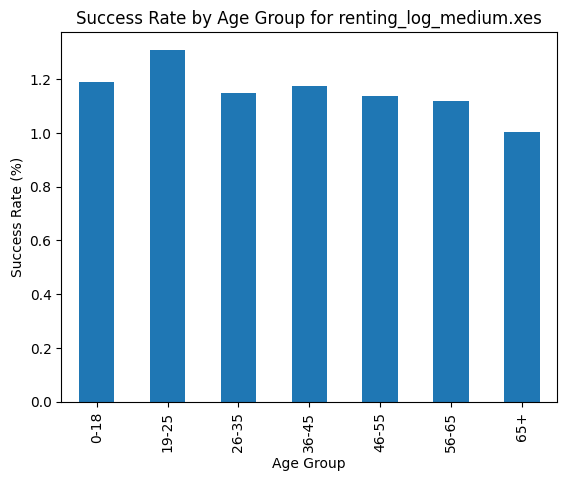

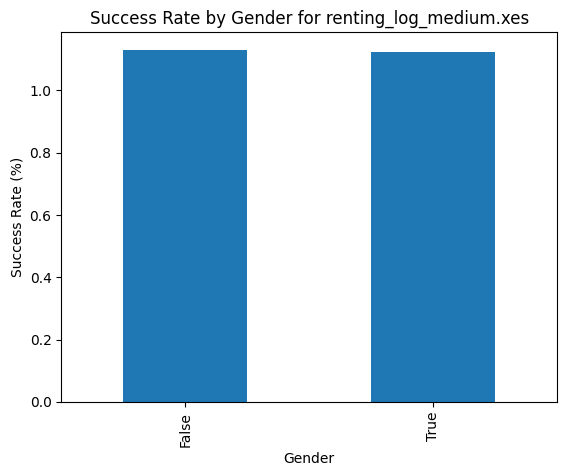

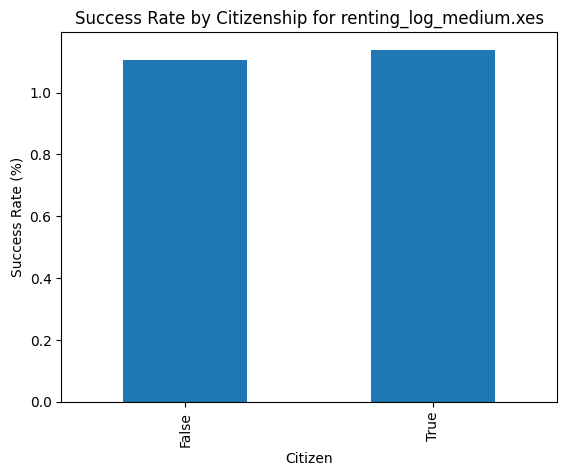

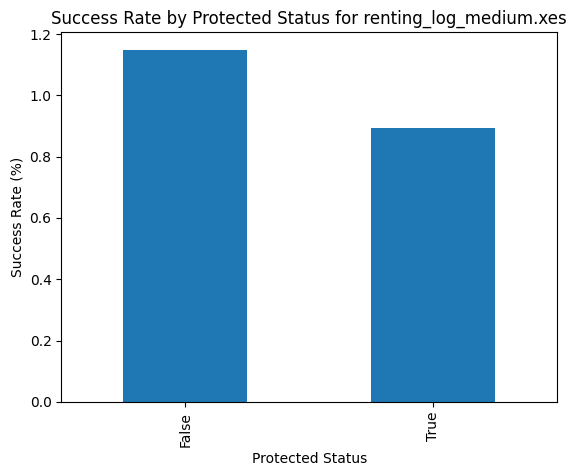

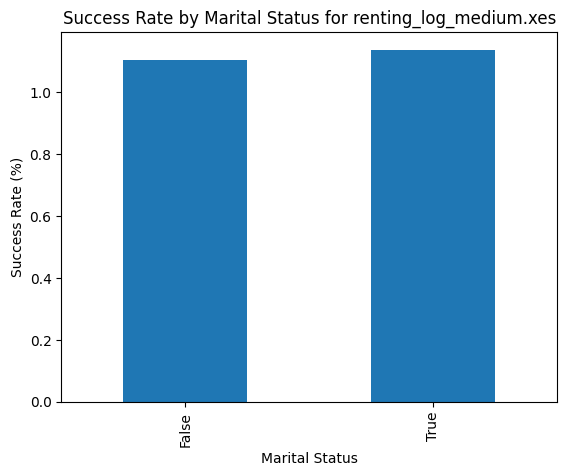

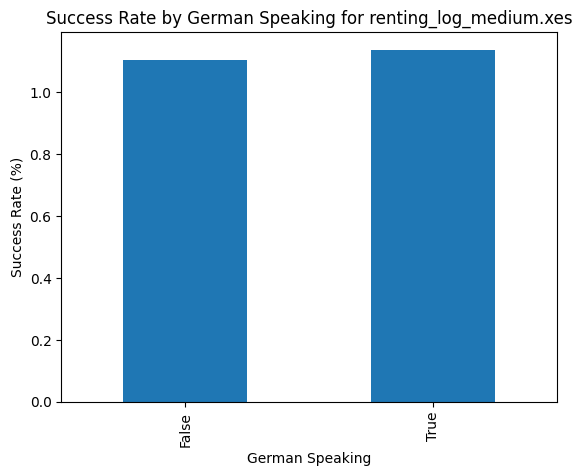

In [7]:
def plot_discriminant_factors(df, log_name):
    # Extract relevant columns for analysis
    df_discriminant = df[['case:yearsOfEducation', 'case:age', 'case:gender', 'case:citizen', 'case:protected', 'case:married', 'case:german speaking', 'activity']]
    
    # Add a 'Success' column based on the 'Sign Contract' activity
    df_discriminant = df_discriminant.copy()
    df_discriminant['Success'] = df_discriminant['activity'].apply(lambda x: 1 if x == 'Sign Contract' else 0)
    
    # Create age bins
    bins = [0, 18, 25, 35, 45, 55, 65, 100]
    labels = ['0-18', '19-25', '26-35', '36-45', '46-55', '56-65', '65+']
    df_discriminant['age_group'] = pd.cut(df_discriminant['case:age'], bins=bins, labels=labels, right=False)
    
    # Plot success rate by years of education
    education_success = df_discriminant.groupby('case:yearsOfEducation')['Success'].mean() * 100 / 3.5
    education_success.plot(kind='bar', title=f'Success Rate by Years of Education for {log_name}')
    plt.xlabel('Years of Education')
    plt.ylabel('Success Rate (%)')
    plt.show()
    
    # Plot success rate by age group
    age_success = df_discriminant.groupby('age_group', observed=False)['Success'].mean() * 100 / 3.5
    age_success.plot(kind='bar', title=f'Success Rate by Age Group for {log_name}')
    plt.xlabel('Age Group')
    plt.ylabel('Success Rate (%)')
    plt.show()
    
    # Plot success rate by gender
    gender_success = df_discriminant.groupby('case:gender', observed=False)['Success'].mean() * 100 / 3.5
    gender_success.plot(kind='bar', title=f'Success Rate by Gender for {log_name}')
    plt.xlabel('Gender')
    plt.ylabel('Success Rate (%)')
    plt.show()
    
    # Plot success rate by citizenship
    citizen_success = df_discriminant.groupby('case:citizen', observed=False)['Success'].mean() * 100 / 3.5
    citizen_success.plot(kind='bar', title=f'Success Rate by Citizenship for {log_name}')
    plt.xlabel('Citizen')
    plt.ylabel('Success Rate (%)')
    plt.show()
    
    # Plot success rate by protected status
    protected_success = df_discriminant.groupby('case:protected', observed=False)['Success'].mean() * 100 / 3.5
    protected_success.plot(kind='bar', title=f'Success Rate by Protected Status for {log_name}')
    plt.xlabel('Protected Status')
    plt.ylabel('Success Rate (%)')
    plt.show()
    
    # Plot success rate by marital status
    married_success = df_discriminant.groupby('case:married', observed=False)['Success'].mean() * 100 / 3.5
    married_success.plot(kind='bar', title=f'Success Rate by Marital Status for {log_name}')
    plt.xlabel('Marital Status')
    plt.ylabel('Success Rate (%)')
    plt.show()
    
    # Plot success rate by german speaking
    german_speaking_success = df_discriminant.groupby('case:german speaking', observed=False)['Success'].mean() * 100 / 3.5
    german_speaking_success.plot(kind='bar', title=f'Success Rate by German Speaking for {log_name}')
    plt.xlabel('German Speaking')
    plt.ylabel('Success Rate (%)')
    plt.show()

for index, event_log in enumerate(event_logs):
    log_name = xes_files[index].split("\\")[-1]
    print("Plot discriminant factors for", log_name)
    plot_discriminant_factors(event_log, log_name)
    if index != len(event_logs) - 1:
        print("-"*25)


## Evaluate models

To evaluate a model, we need 4 metrics :
<center>
Fitness, Precision, Generaliszation and Simplicity
</center>

In [14]:
from pm4py.algo.evaluation.generalization import algorithm as generalization_evaluator
from pm4py.algo.evaluation.simplicity import algorithm as simplicity_evaluator

def generic_model_evaluator(event_log, net, initial_marking, final_marking, log_name="alpha miner"):
    evaluation = {}
    fitness = pm4py.fitness_token_based_replay(event_log, net, initial_marking, final_marking)
    evaluation['fitness_tbr'] = fitness
    prec = pm4py.precision_token_based_replay(event_log, net, initial_marking, final_marking)
    evaluation['precision_tbr'] = prec
    gen = generalization_evaluator.apply(event_log, net, initial_marking, final_marking)
    evaluation['generalization'] = gen
    simp = simplicity_evaluator.apply(net)
    evaluation['simplicity'] = simp
    
    TP = fitness['average_trace_fitness'] * 100
    FP = (1 - prec) * 100
    FN = (1 - gen) * 100
    TN = simp * 100

    table_of_truth = pd.DataFrame([[TP, FP], [FN, TN]], columns=['Positive', 'Negative'], index=['Positive', 'Negative'])
    evaluation['table_of_truth'] = table_of_truth

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0 # nbTraceByModel / nbTraceInLog
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    evaluation['precision'] = precision
    evaluation['recall'] = recall
    evaluation['f_score'] = f_score

    if "alpha miner" not in log_name: # Deny conformance checking for Petri nets (else it will throw an error)
        precision_alignments = pm4py.conformance.precision_alignments(event_log, net, initial_marking, final_marking)
        evaluation['precision_alignments'] = precision_alignments
        # print(f"Precision (alignments): {precision_alignments}")
    
    return evaluation

def show_model_evaluation(models):
    for index, model in enumerate(models):
        log_name = list(model.keys())[0]
        net = list(model.values())[0]['net']
        initial_marking = list(model.values())[0]['initial_marking']
        final_marking = list(model.values())[0]['final_marking']
        event_log = event_logs[index]
        print("Evaluating model for", log_name)
        evaluation = generic_model_evaluator(event_log, net, initial_marking, final_marking)

        for key, value in evaluation.items():
            if key == 'table_of_truth':
                print("Table of Truth:")
                print(value)
            elif key == 'precision' or key == 'recall' or key == 'f_score':
                print(f"{key.capitalize()}: {value}")
            elif key == 'precision_alignments':
                print(f"Precision (alignments): {value}")
            else:
                print(f"{key.capitalize()}: {value}")
        
        if index != len(models) - 1:
            print("-"*25)

In [13]:
# Evaluate the models discovered by the alpha miner
show_model_evaluation(alpha_models)

Evaluating model for renting_log_high.xes (Petri from alpha miner)


replaying log with TBR, completed traces :: 100%|██████████| 496/496 [00:00<00:00, 779.96it/s]


Fitness_tbr: {'perc_fit_traces': 0.0, 'average_trace_fitness': 0.7663591440362545, 'log_fitness': 0.7577831470093864, 'percentage_of_fitting_traces': 0.0}
Precision_tbr: 0.36027325985157066
Generalization: 0.9771404952380432
Simplicity: 0.6153846153846154
Table of Truth:
           Positive   Negative
Positive  76.635914  63.972674
Negative   2.285950  61.538462
Precision: 0.5450301099357286
Recall: 0.9710352703946286
F_score: 0.6981802592963767
-------------------------
Evaluating model for renting_log_low.xes (Petri from alpha miner)


replaying log with TBR, completed traces :: 100%|██████████| 508/508 [00:01<00:00, 454.56it/s]


Fitness_tbr: {'perc_fit_traces': 0.0, 'average_trace_fitness': 0.7645500828761987, 'log_fitness': 0.756450414094077, 'percentage_of_fitting_traces': 0.0}
Precision_tbr: 0.36130451391884066
Generalization: 0.9791394702792057
Simplicity: 0.6153846153846154
Table of Truth:
           Positive   Negative
Positive  76.455008  63.869549
Negative   2.086053  61.538462
Precision: 0.5448441098191217
Recall: 0.9734399696334405
F_score: 0.6986479551422522
-------------------------
Evaluating model for renting_log_medium.xes (Petri from alpha miner)


replaying log with TBR, completed traces :: 100%|██████████| 610/610 [00:00<00:00, 781.28it/s]


Fitness_tbr: {'perc_fit_traces': 0.0, 'average_trace_fitness': 0.7645333283692183, 'log_fitness': 0.7572269639156843, 'percentage_of_fitting_traces': 0.0}
Precision_tbr: 0.3648994466806551
Generalization: 0.9814208798428365
Simplicity: 0.6153846153846154
Table of Truth:
           Positive   Negative
Positive  76.453333  63.510055
Negative   1.857912  61.538462
Precision: 0.5462380829527081
Recall: 0.9762752843577897
F_score: 0.7005242137265957


Petri net discovered for file renting_log_high.xes


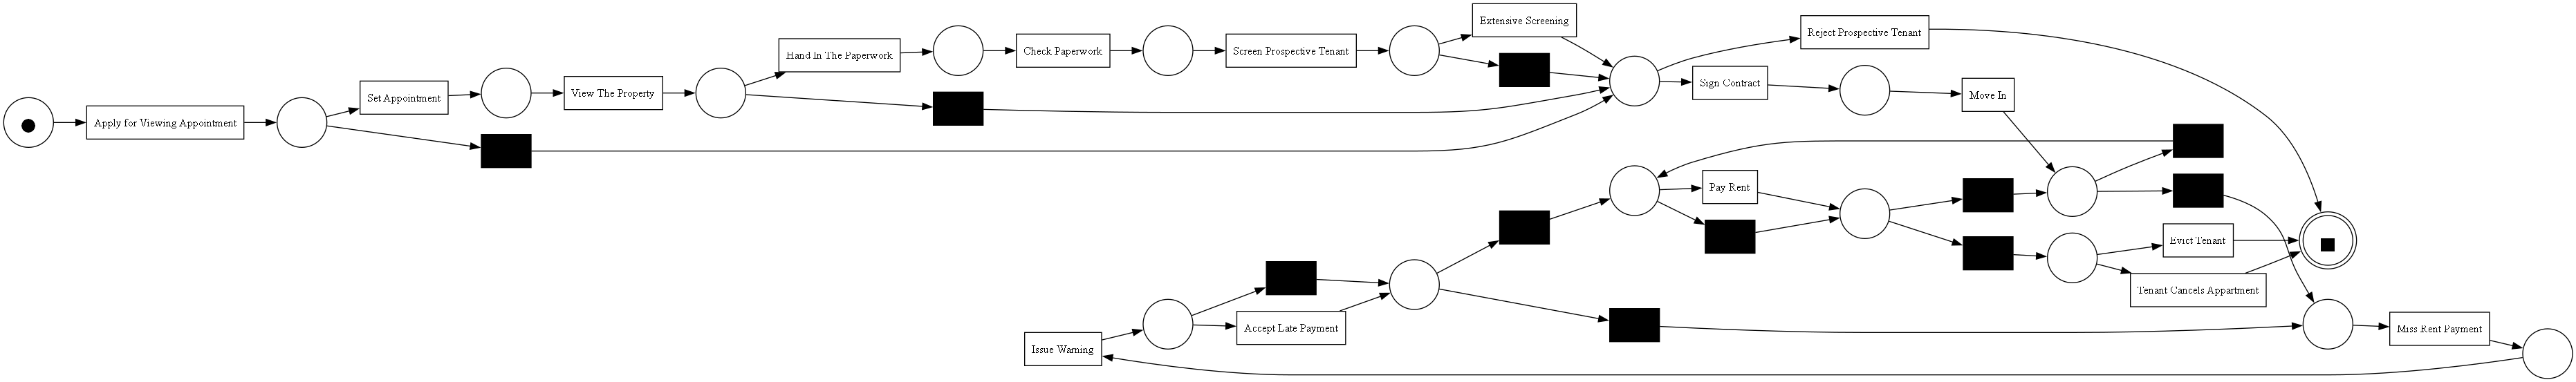

Petri net discovered for file renting_log_low.xes


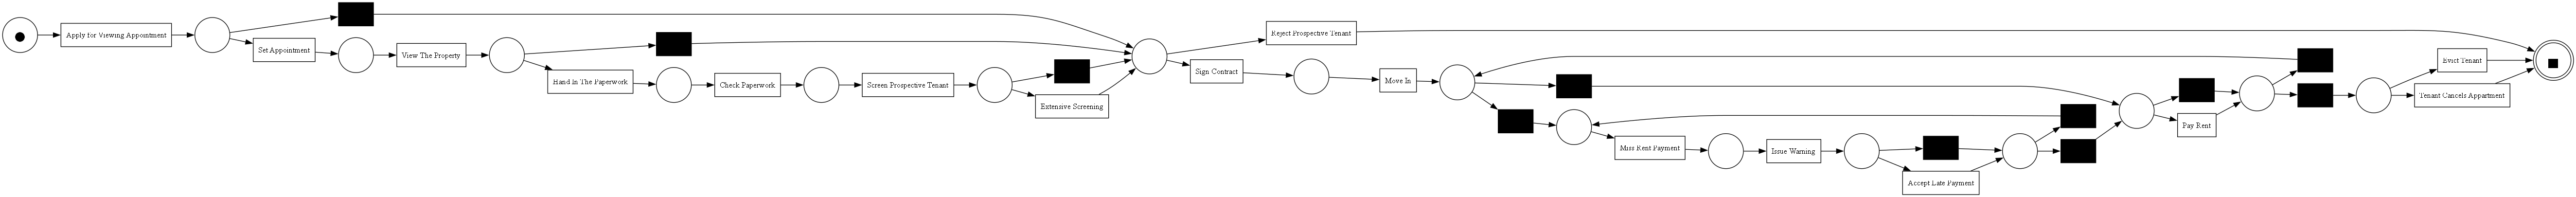

Petri net discovered for file renting_log_medium.xes


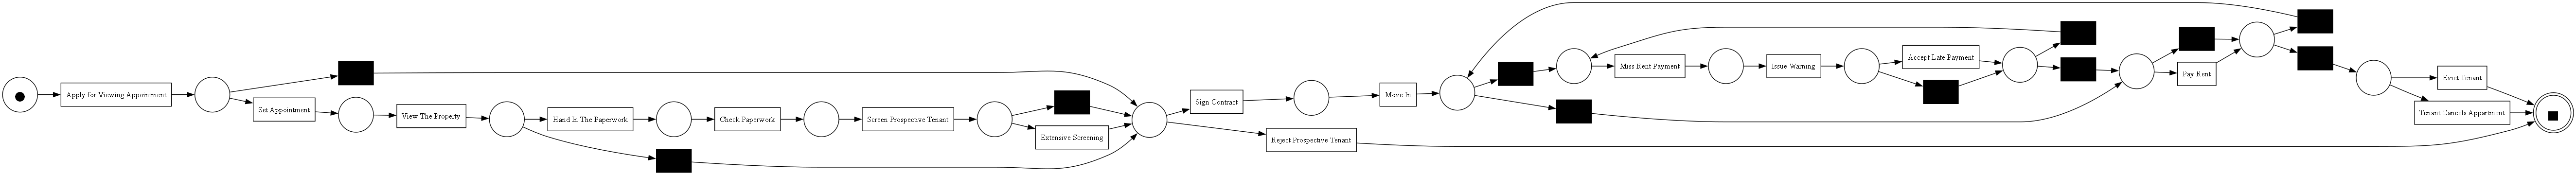

Evaluating model for renting_log_high.xes (Petri from inductive miner)


replaying log with TBR, completed traces :: 100%|██████████| 496/496 [00:01<00:00, 422.16it/s]


Fitness_tbr: {'perc_fit_traces': 100.0, 'average_trace_fitness': 1.0, 'log_fitness': 1.0, 'percentage_of_fitting_traces': 100.0}
Precision_tbr: 0.8189841663196595
Generalization: 0.9674215082609988
Simplicity: 0.7142857142857143
Table of Truth:
            Positive   Negative
Positive  100.000000  18.101583
Negative    3.257849  71.428571
Precision: 0.846728698703175
Recall: 0.9684493798780037
F_score: 0.9035079178842409
-------------------------
Evaluating model for renting_log_low.xes (Petri from inductive miner)


replaying log with TBR, completed traces :: 100%|██████████| 508/508 [00:01<00:00, 418.00it/s]


Fitness_tbr: {'perc_fit_traces': 100.0, 'average_trace_fitness': 1.0, 'log_fitness': 1.0, 'percentage_of_fitting_traces': 100.0}
Precision_tbr: 0.820816169981883
Generalization: 0.9687499384956054
Simplicity: 0.7142857142857143
Table of Truth:
            Positive   Negative
Positive  100.000000  17.918383
Negative    3.125006  71.428571
Precision: 0.848044193401665
Recall: 0.9696969118636397
F_score: 0.9047997353236527
-------------------------
Evaluating model for renting_log_medium.xes (Petri from inductive miner)


replaying log with TBR, completed traces :: 100%|██████████| 610/610 [00:01<00:00, 462.64it/s]


Fitness_tbr: {'perc_fit_traces': 100.0, 'average_trace_fitness': 1.0, 'log_fitness': 1.0, 'percentage_of_fitting_traces': 100.0}
Precision_tbr: 0.8146649908579642
Generalization: 0.9732368797953215
Simplicity: 0.7142857142857143
Table of Truth:
            Positive   Negative
Positive  100.000000  18.533501
Negative    2.676312  71.428571
Precision: 0.8436433517000529
Recall: 0.973934474585196
F_score: 0.9041190232327749


In [10]:
# Discover models using Inductive Miner
inductive_models = []

for index, event_log in enumerate(event_logs):
    file_name = xes_files[index].split("\\")[-1]
    net, initial_marking, final_marking = pm4py.discover_petri_net_inductive(event_log)
    inductive_models.append({file_name + " (Petri from inductive miner)" : {"net": net, "initial_marking" : initial_marking, "final_marking" : final_marking}})
    print("Petri net discovered for file", file_name)
    pm4py.view_petri_net(net, initial_marking, final_marking)

show_model_evaluation(inductive_models)

Petri net discovered for file renting_log_high.xes


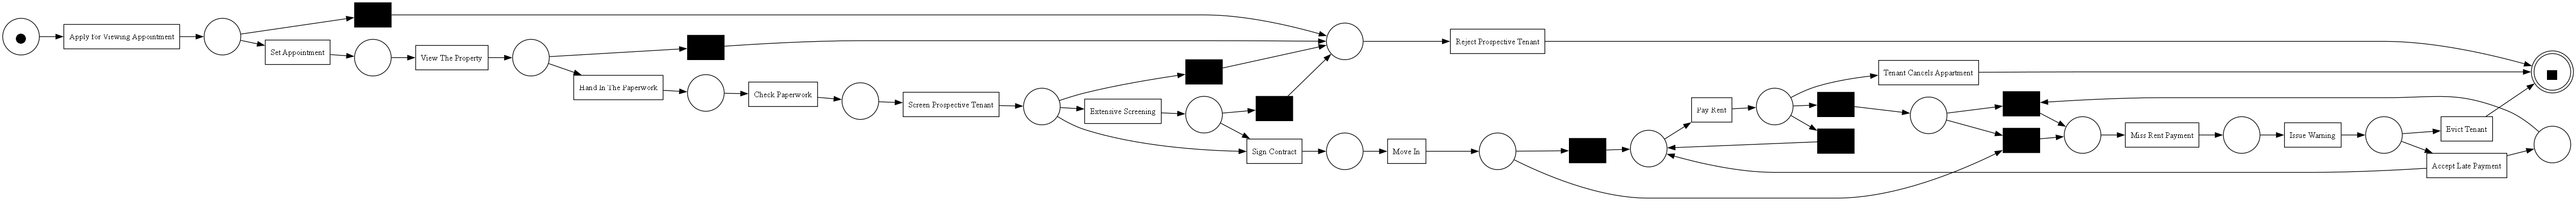

Petri net discovered for file renting_log_low.xes


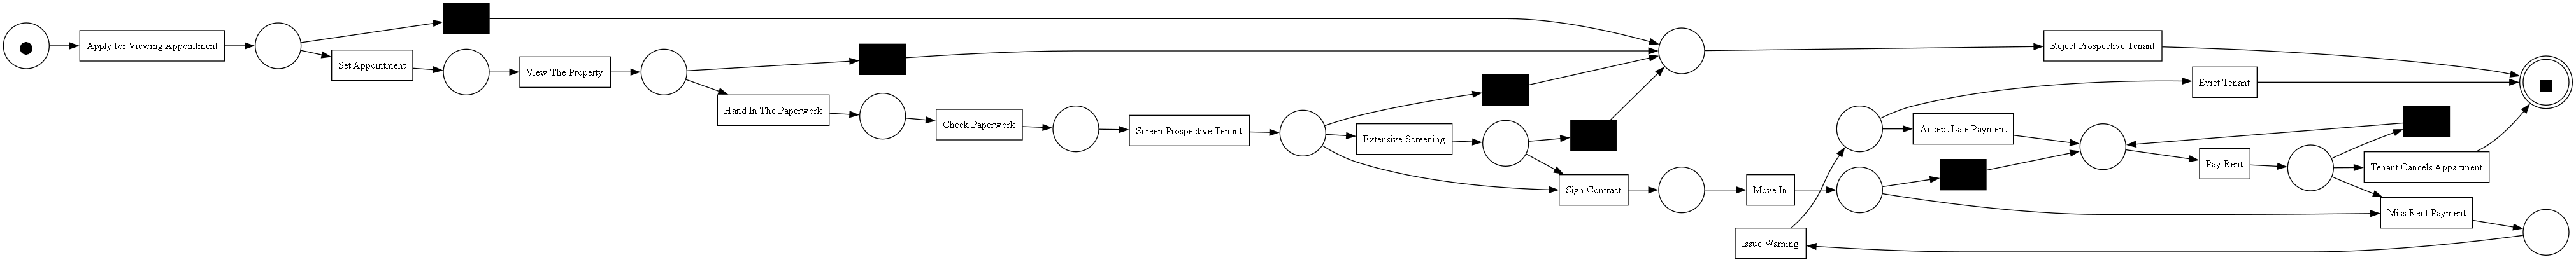

Petri net discovered for file renting_log_medium.xes


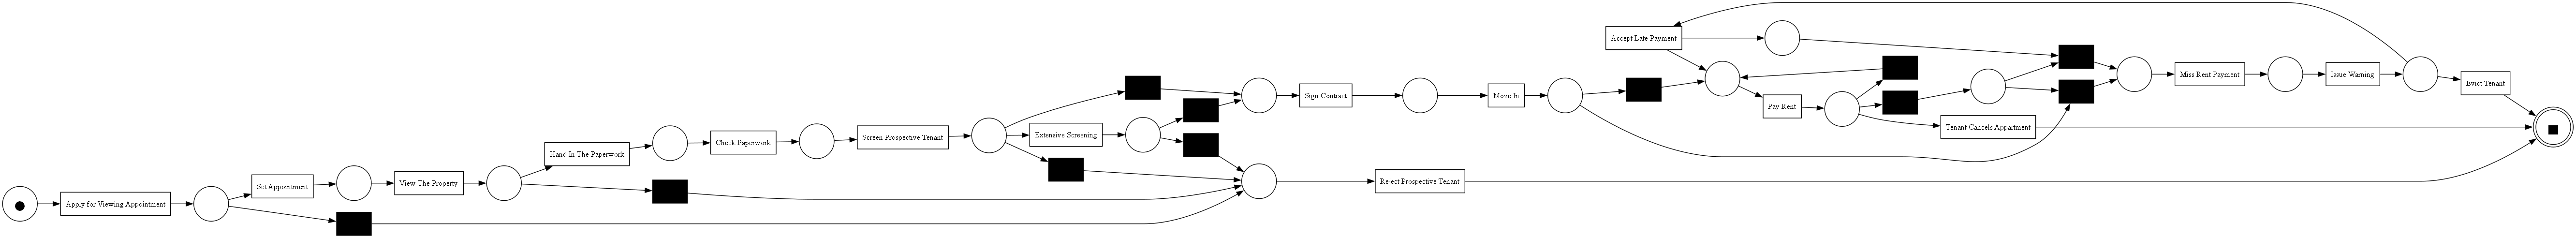

Evaluating model for renting_log_high.xes (Petri from heuristics miner)


replaying log with TBR, completed traces :: 100%|██████████| 496/496 [00:01<00:00, 461.45it/s]


Fitness_tbr: {'perc_fit_traces': 72.3, 'average_trace_fitness': 0.9901552959789598, 'log_fitness': 0.9812015716188836, 'percentage_of_fitting_traces': 72.3}
Precision_tbr: 1.0
Generalization: 0.9581785650901375
Simplicity: 0.6875
Table of Truth:
           Positive  Negative
Positive  99.015530      0.00
Negative   4.182143     68.75
Precision: 1.0
Recall: 0.9594744400158689
F_score: 0.9793181481949809
-------------------------
Evaluating model for renting_log_low.xes (Petri from heuristics miner)


replaying log with TBR, completed traces :: 100%|██████████| 508/508 [00:01<00:00, 504.60it/s]


Fitness_tbr: {'perc_fit_traces': 65.9, 'average_trace_fitness': 0.9898762345133478, 'log_fitness': 0.9834542986165368, 'percentage_of_fitting_traces': 65.9}
Precision_tbr: 1.0
Generalization: 0.9786684787566609
Simplicity: 0.7037037037037037
Table of Truth:
           Positive  Negative
Positive  98.987623   0.00000
Negative   2.133152  70.37037
Precision: 1.0
Recall: 0.9789049074021621
F_score: 0.9893400170372356
-------------------------
Evaluating model for renting_log_medium.xes (Petri from heuristics miner)


replaying log with TBR, completed traces :: 100%|██████████| 610/610 [00:01<00:00, 307.77it/s]


Fitness_tbr: {'perc_fit_traces': 88.75, 'average_trace_fitness': 0.994630412418541, 'log_fitness': 0.9895682943270854, 'percentage_of_fitting_traces': 88.75}
Precision_tbr: 0.999892373678588
Generalization: 0.9656151527306073
Simplicity: 0.7014925373134328
Table of Truth:
           Positive   Negative
Positive  99.463041   0.010763
Negative   3.438485  70.149254
Precision: 0.9998918043573075
Recall: 0.9665847061589538
F_score: 0.9829561865976452


In [11]:
# Discover models using Inductive Miner
inductive_models = []

for index, event_log in enumerate(event_logs):
    file_name = xes_files[index].split("\\")[-1]
    net, initial_marking, final_marking = pm4py.discover_petri_net_heuristics(event_log)
    inductive_models.append({file_name + " (Petri from heuristics miner)" : {"net": net, "initial_marking" : initial_marking, "final_marking" : final_marking}})
    print("Petri net discovered for file", file_name)
    pm4py.view_petri_net(net, initial_marking, final_marking)

show_model_evaluation(inductive_models)